In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from anesthetic import read_chains

from nestar.ARIMA import ARIMA_fast
from nestar.ARIMA_ns import ARIMA_Nested_Sampler
from nestar.model_comparison_utils import ARIMA_model_comparison
from nestar import arima_results as ar


In [6]:
dta = sm.datasets.sunspots.load_pandas().data
dta.index = pd.Index(sm.tsa.datetools.dates_from_range("1700", "2008"))
dta.index.freq = dta.index.inferred_freq
time = dta["YEAR"]
del dta["YEAR"]

Text(0.5, 1.0, 'Number of Sunspots vs Year')

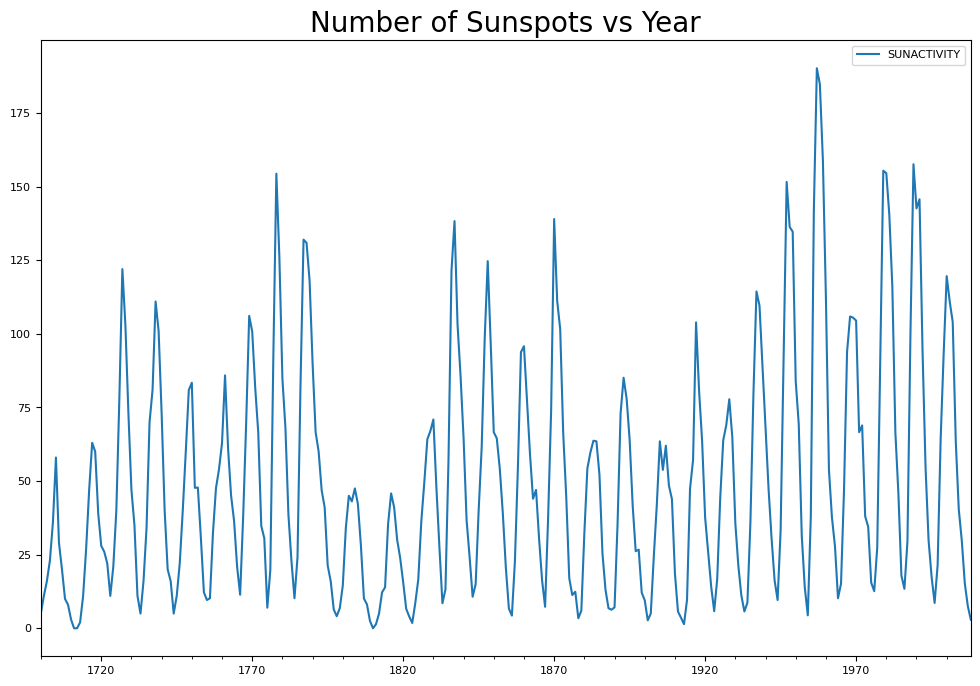

In [7]:
dta.plot(figsize=(12, 8))
plt.title('Number of Sunspots vs Year',fontsize=20)

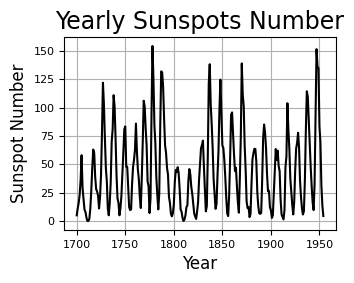

In [8]:
counts = dta['SUNACTIVITY'].to_numpy()
final_index = 255
training_dataset = counts[:255]
training_time = time[:255]
plt.figure(figsize=(3.5, 2.5))  # inches
plt.rcParams.update({'font.size': 8})
plt.plot(training_time,training_dataset,color='black')
plt.xlabel('Year',fontsize=12)
plt.ylabel('Sunspot Number',fontsize=12)
plt.title('Yearly Sunspots Number',fontsize=17)
plt.grid()

In [9]:
from model_comparison_utils import stationarity_test
stationarity_test(training_dataset)

Results of Dickey-Fuller Test:
Test Statistic                  -2.931083
p-value                          0.041851
#Lags Used                       8.000000
Number of Observations Used    246.000000
Critical Value (1%)             -3.457215
Critical Value (5%)             -2.873362
Critical Value (10%)            -2.573070
dtype: float64
Series stationary acc to ADF Test
Results of KPSS Test:
Test Statistic           0.124768
p-value                  0.100000
Lags Used                7.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64
Series stationarity acc to KPSS test


/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_comparison_utils.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")
/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_comparison_utils.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if kpss_output[1] < 0.05:


(None, None)

In [ ]:
model_comparison = ARIMA_model_comparison(data=training_dataset,max_p=10,max_q=10,d=0,num_live=500,num_delete=50,seed=20,mu_mean=0,mu_scale=50,prior_scale=0.8,file_name='sunspots_logP.txt')

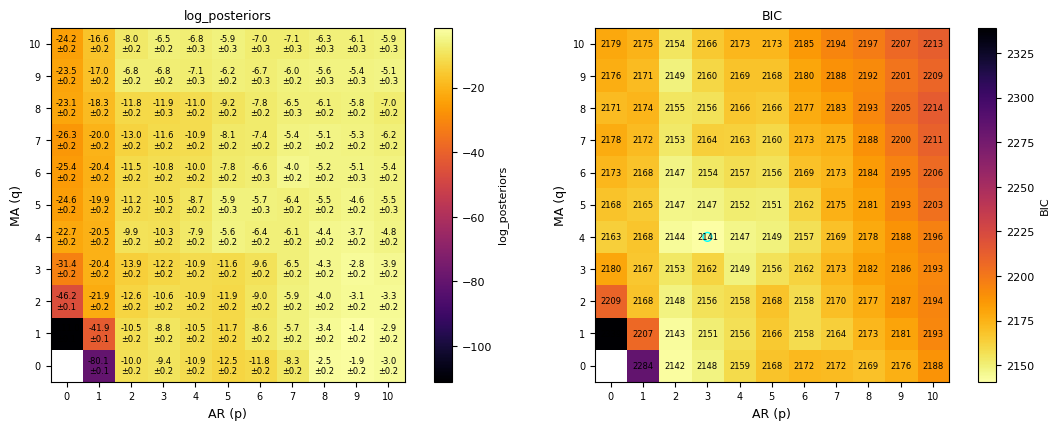

In [30]:
model_comparison.compare(quantity2="BIC",highlight_max=(False,True),value_fmt=("{:.1f}","{:.0f}"))
plt.show()

{'order_of_interest': (9, 0, 1), 'baseline_order': (0, 0, 1), 'raw_log_posterior_delta': 109.6626009335157, 'log_V_boost_delta': 6.094881668285872, 'd0_occam_delta': -2.309776987828113, 'net_prior_volume_delta': 3.7851046804577595, 'likelihood_only_delta': 105.87749625305794, 'fraction_of_raw_delta_from_prior_volume': 0.034515911972145596}


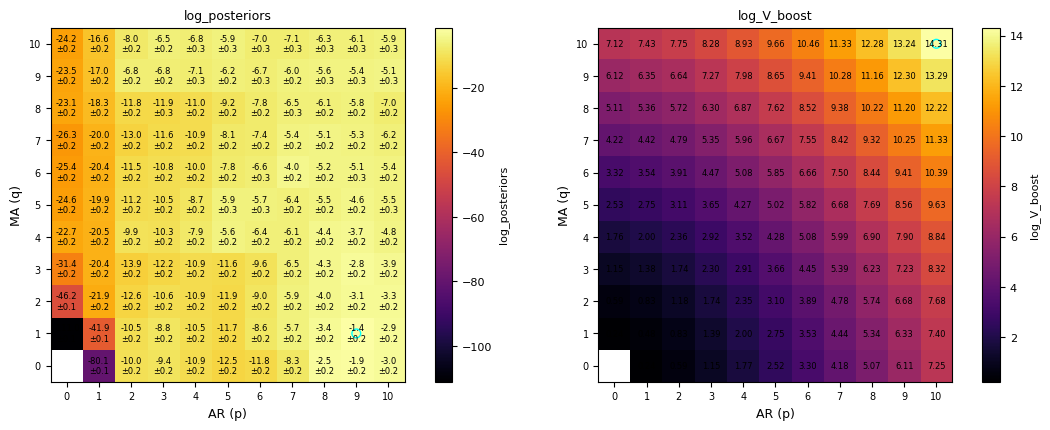

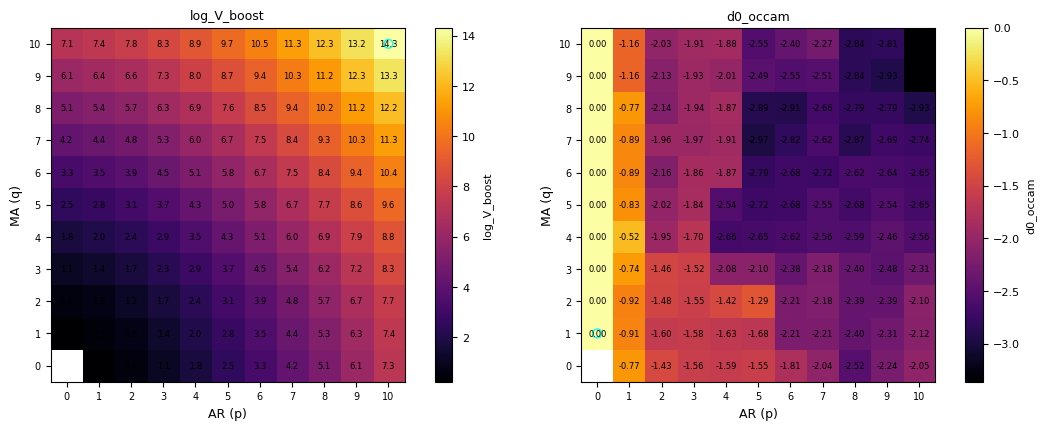

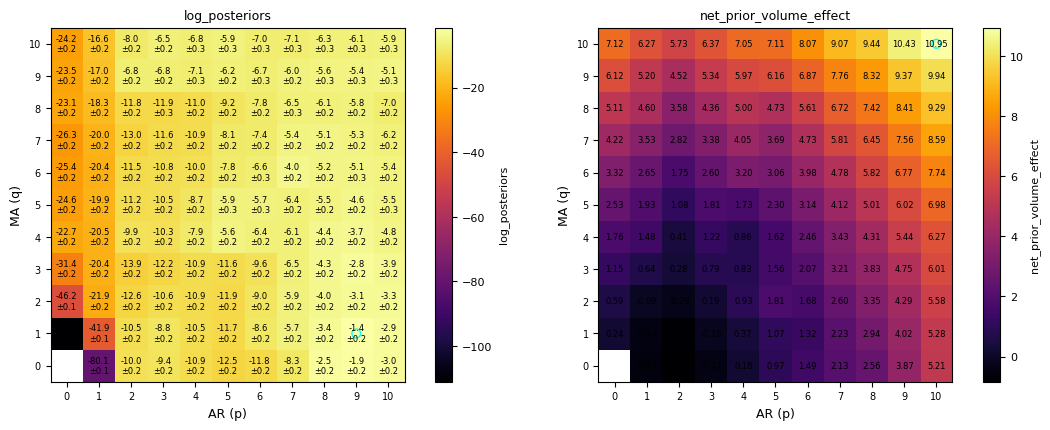

In [ ]:
model_comparison.compare("log_posteriors", "log_V_boost")

# item 3c: V and D0 side by side, then combined
model_comparison.compare("log_V_boost", "d0_occam")
model_comparison.compare("log_posteriors", "net_prior_volume_effect")

report = model_comparison.prior_volume_report(order_of_interest=(9, 0, 1), baseline_order=(0, 0, 1))
print(report)

In [36]:
for baseline in [(0,0,1),(3,0,4),(5,0,4),(8,0,0),(9,0,0),(10,0,0),(8,0,1),(10,0,1),(8,0,2),(9,0,2),(10,0,2)]:
    report = model_comparison.prior_volume_report(order_of_interest=(9, 0, 1), baseline_order=baseline)
    print(report)


{'order_of_interest': (9, 0, 1), 'baseline_order': (0, 0, 1), 'raw_log_posterior_delta': 109.6626009335157, 'log_V_boost_delta': 6.094881668285872, 'd0_occam_delta': -2.309776987828113, 'net_prior_volume_delta': 3.7851046804577595, 'likelihood_only_delta': 105.87749625305794, 'fraction_of_raw_delta_from_prior_volume': 0.034515911972145596}
{'order_of_interest': (9, 0, 1), 'baseline_order': (3, 0, 4), 'raw_log_posterior_delta': 8.952361647816588, 'log_V_boost_delta': 3.4156037953199134, 'd0_occam_delta': -0.610614628939415, 'net_prior_volume_delta': 2.8049891663804987, 'likelihood_only_delta': 6.147372481436089, 'fraction_of_raw_delta_from_prior_volume': 0.31332393358624133}
{'order_of_interest': (9, 0, 1), 'baseline_order': (5, 0, 4), 'raw_log_posterior_delta': 4.252557853231792, 'log_V_boost_delta': 2.0572626399602694, 'd0_occam_delta': 0.3425599595952886, 'net_prior_volume_delta': 2.399822599555558, 'likelihood_only_delta': 1.8527352536762343, 'fraction_of_raw_delta_from_prior_volume

In [25]:
model_comparison_pacf = ARIMA_model_comparison(data=training_dataset,max_p=10,max_q=10,d=0,num_live=500,num_delete=50,seed=25,mu_mean=0,mu_scale=50,prior_scale=1,prior_type="pacf",file_name='sunspots_logP_pacf.txt')
model_comparison_pacf.run()

Running Nested Sampling for fitting ARIMA (0, 0, 1) model...


Dead points: 7900 dead points [00:02, 3036.72 dead points/s]


Finished Nested Sampling with a total runtime of : 3.00 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 0, 1) : -1170.9458816325348 ; Error : 0.11946964322403902
V : 1.0 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.000
Highest Evidence so far : -1170.9458816325348 for order : (0, 0, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 0, 2) model...


Dead points: 9200 dead points [00:03, 2351.21 dead points/s]


Finished Nested Sampling with a total runtime of : 4.25 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 0, 2) : -1106.032848363019 ; Error : 0.18164413573226462
V : 1.0 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.000
Highest Evidence so far : -1106.032848363019 for order : (0, 0, 2)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 0, 3) model...


...

Finished Nested Sampling with a total runtime of : 301.64 seconds
----------------------x-------------------x---------------------x------
Evidence for (10, 0, 8) : -1073.3877139345097 ; Error : 0.24567304801202028
V : 1.0 ; D0 Occam : -4.776 ; Net prior-volume effect : -4.776
Highest Evidence so far : -1064.5863037078188 for order : (5, 0, 4)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (10, 0, 9) model...


Dead points: 28650 dead points [05:32, 86.20 dead points/s]


Finished Nested Sampling with a total runtime of : 333.72 seconds
----------------------x-------------------x---------------------x------
Evidence for (10, 0, 9) : -1072.9472686440754 ; Error : 0.30186188627939575
V : 1.0 ; D0 Occam : -4.673 ; Net prior-volume effect : -4.673
Highest Evidence so far : -1064.5863037078188 for order : (5, 0, 4)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (10, 0, 10) model...


Dead points: 29850 dead points [06:06, 81.46 dead points/s]


Finished Nested Sampling with a total runtime of : 367.81 seconds
----------------------x-------------------x---------------------x------
Evidence for (10, 0, 10) : -1074.371512809442 ; Error : 0.24816587763454748
V : 1.0 ; D0 Occam : -4.808 ; Net prior-volume effect : -4.808
Highest Evidence so far : -1064.5863037078188 for order : (5, 0, 4)
----------------------x-------------------x----------------------x-----


Running Nested Sampling for fitting ARIMA (9, 0, 1) model...


Dead points: 34400 dead points [09:26, 60.73 dead points/s]


Finished Nested Sampling with a total runtime of : 567.50 seconds
||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 567.50 seconds
----------------------------------------------------
Posterior mean for phi_1 : 0.9170909256290694
Posterior mean for phi_2 : -0.07541160752375359
Posterior mean for phi_3 : -0.29689742102245464
Posterior mean for phi_4 : 0.13528933262095189
Posterior mean for phi_5 : -0.08173783533570717
Posterior mean for phi_6 : -0.013563395876116564
Posterior mean for phi_7 : -0.025790494993175022
Posterior mean for phi_8 : 0.06075430497980014
Posterior mean for phi_9 : 0.18308690310484615
Posterior mean for theta_1 : 0.27144646443944104
Posterior mean for sigma : 14.305526934790244
Posterior mean for mu : 46.80310748771708
Posterior mean for init_y_1 : -6.8657788090750005
Posterior mean for init_y_2 : -13.408885173008738
Posterior mean for init_y_3 : -16.83297890087761
Posterior mean for init_y_4 : 32.7566

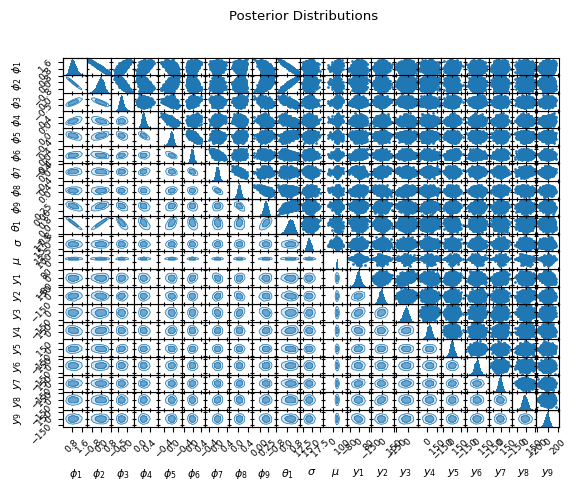

In [7]:
arma91_model = ARIMA_ns.ARIMA_Nested_Sampler(data=training_dataset,order=(9,0,1),mu_mean=0,mu_scale=50,num_live=1000,num_delete=50,seed=53,prior_scale=0.8)
arma91_model.summary()

In [30]:
#sp_arma_91_samples = arma91_model.posterior_samples
#sp_arma_91_samples.to_csv('NS Chains/sunspots_arma91_samples_new.csv')
sp_arma_91_samples= read_chains('NS Chains/sunspots_arma91_samples_new.csv')

Running Nested Sampling for fitting ARIMA (3, 0, 4) model...


Dead points: 37150 dead points [05:19, 116.44 dead points/s]


Finished Nested Sampling with a total runtime of : 320.20 seconds
||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 320.20 seconds
----------------------------------------------------
Posterior mean for phi_1 : 1.2907461524646315
Posterior mean for phi_2 : -0.5206334540243706
Posterior mean for phi_3 : -0.17809671781741326
Posterior mean for theta_1 : -0.05101962310041707
Posterior mean for theta_2 : 0.0021450493873561003
Posterior mean for theta_3 : 0.042877666717577465
Posterior mean for theta_4 : 0.2541580793907915
Posterior mean for sigma : 14.916682348228733
Posterior mean for mu : 44.77238024714129
Posterior mean for init_y_1 : 5.358054965018087
Posterior mean for init_y_2 : 28.645137620019668
Posterior mean for init_y_3 : 7.218043299816904
---------------------------------------------------
Log Evidence: -1070.39 ± 0.14
-------x----------------x-------------x------------


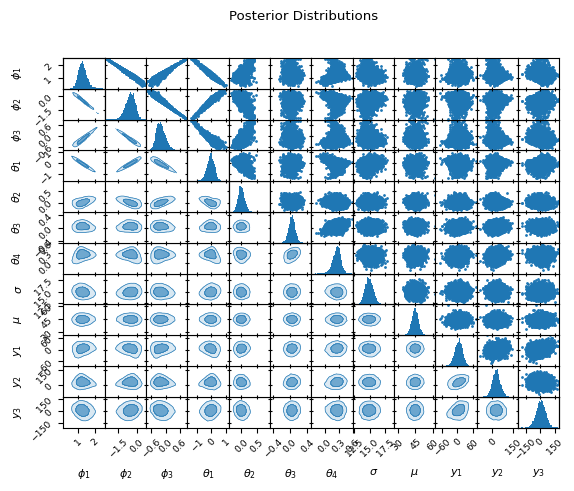

In [31]:
arma34_model = ARIMA_ns.ARIMA_Nested_Sampler(data=training_dataset,order=(3,0,4),mu_mean=0,mu_scale=50,num_live=1000,num_delete=50,seed=53,prior_scale=0.8)
arma34_model.summary()

Running Nested Sampling for fitting ARIMA (5, 0, 4) model...


Dead points: 39600 dead points [03:06, 211.77 dead points/s]


Finished Nested Sampling with a total runtime of : 188.60 seconds
||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 188.60 seconds
----------------------------------------------------
Posterior mean for alpha_ar_1 : 0.8961005234879604
Posterior mean for alpha_ar_2 : -0.7997714104665281
Posterior mean for alpha_ar_3 : 0.028284050469162554
Posterior mean for alpha_ar_4 : 0.438380170853675
Posterior mean for alpha_ar_5 : 0.3629044046547577
Posterior mean for alpha_ma_1 : 0.40404644028921705
Posterior mean for alpha_ma_2 : 0.3199752836020182
Posterior mean for alpha_ma_3 : 0.04860728947011722
Posterior mean for alpha_ma_4 : -0.44150549316825366
Posterior mean for sigma : 14.339998739798716
Posterior mean for mu : 45.15664537228638
Posterior mean for init_y_1 : -2.7720835949029508
Posterior mean for init_y_2 : -5.3285325059460105
Posterior mean for init_y_3 : 2.729830098329655
Posterior mean for init_y_4 : 0.6764708331403586
Po

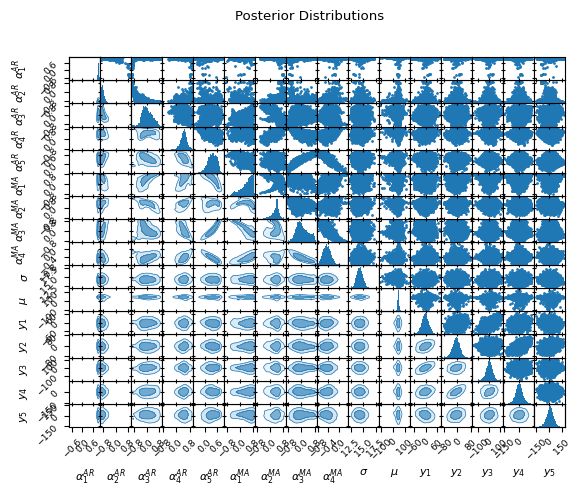

In [35]:
arma54_model = ARIMA_ns.ARIMA_Nested_Sampler(data=training_dataset,order=(5,0,4),mu_mean=0,mu_scale=50,num_live=1000,num_delete=50,seed=53,prior_scale=0.8,prior_type="pacf")
arma54_model.summary()

In [36]:
sunspots_arma54_samples = arma54_model.posterior_samples
arma54_model.posterior_samples.to_csv("NS Chains/sunspots_arma54_samples_new.csv")

In [32]:
sunspots_arma33_samples = arma34_model.posterior_samples
arma34_model.posterior_samples.to_csv('NS Chains/sunspots_arma34_samples_new.csv')
sp_arma_33_samples= read_chains('NS Chains/sunspots_arma34_samples_new.csv')

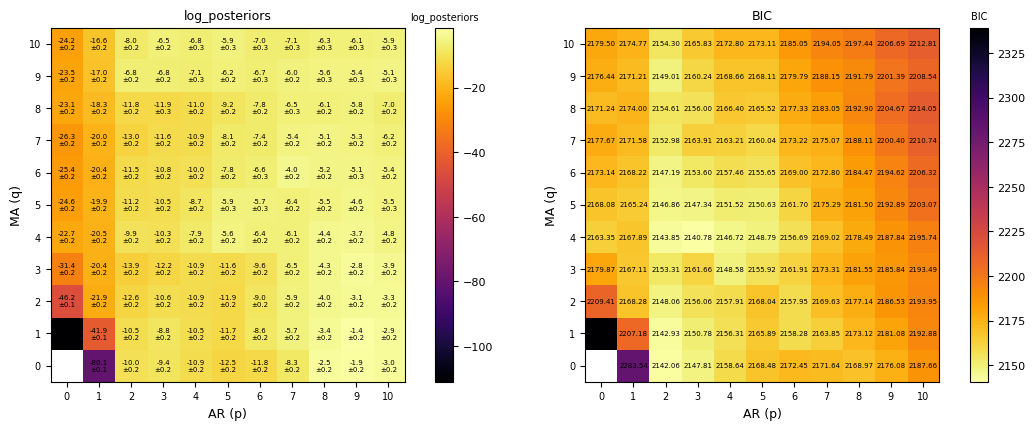

In [5]:
evidence_data = ar.EvidenceResults("Heatmap Data/sunspots_logP.txt",max_p=10,max_q=10)
evidence_data.compare(quantity2="BIC")
plt.show()

In [6]:
logP = evidence_data.log_posteriors
logP_err = evidence_data.evidence_err
print(f"Max evidence for ARIMA(9,0,1) with logP: {max(logP)} and error:{logP_err[np.argmax(logP)]}")

Max evidence for ARIMA(9,0,1) with logP: -1.3863264973729201 and error:0.20813023587085425


In [6]:
evidence_data.cumulative_posterior_mass(5)

{'n': 5,
 'top_orders': [(9, 0, 1), (9, 0, 0), (8, 0, 0), (9, 0, 3), (10, 0, 1)],
 'individual_mass': array([0.24999197, 0.14897813, 0.07918619, 0.06108787, 0.0556656 ]),
 'cumulative_mass': 0.5949097624157299}

In [62]:
##Tau sensitivity checks around best-fit neighbour and extreme models:
orders = [(9,0,1),(9,0,0),(9,0,2),(8,0,1),(8,0,0),(8,0,2),(10,0,1),(10,0,0),(10,0,2)]

tau_evidences = []
tau_err = []
for tau in [16.7,150]:
 neighbour_evidences = []
 neighbour_evidences_err = []
 for order in orders:
    test_model = ARIMA_ns.ARIMA_Nested_Sampler(data=training_dataset,order=order,num_live=100,num_delete=50,mu_mean=0,mu_scale=tau,seed=30)
    evidence = test_model.log_evidence
    neighbour_evidences.append(evidence)
    neighbour_evidences_err.append(test_model.log_evidence_err)
 tau_evidences.append(neighbour_evidences)
 tau_err.append(neighbour_evidences_err)


Running Nested Sampling for fitting ARIMA (9, 0, 1) model...
Acceptance rate: 0.0003, Total drawn: 200000
Acceptance rate: 0.0003, Total drawn: 300000
Acceptance rate: 0.0003, Total drawn: 400000


Dead points: 2550 dead points [00:53, 47.96 dead points/s]


Finished Nested Sampling with a total runtime of : 53.62 seconds
Running Nested Sampling for fitting ARIMA (9, 0, 0) model...
Acceptance rate: 0.0004, Total drawn: 200000
Acceptance rate: 0.0004, Total drawn: 300000


Dead points: 2500 dead points [00:45, 54.62 dead points/s]


Finished Nested Sampling with a total runtime of : 46.14 seconds
Running Nested Sampling for fitting ARIMA (9, 0, 2) model...
Acceptance rate: 0.0002, Total drawn: 200000
Acceptance rate: 0.0002, Total drawn: 300000
Acceptance rate: 0.0002, Total drawn: 400000
Acceptance rate: 0.0002, Total drawn: 500000
Acceptance rate: 0.0002, Total drawn: 600000


...

Finished Nested Sampling with a total runtime of : 90.25 seconds
Running Nested Sampling for fitting ARIMA (10, 0, 0) model...
Acceptance rate: 0.0001, Total drawn: 200000
Acceptance rate: 0.0001, Total drawn: 300000
Acceptance rate: 0.0001, Total drawn: 400000
Acceptance rate: 0.0001, Total drawn: 500000
Acceptance rate: 0.0001, Total drawn: 600000
Acceptance rate: 0.0001, Total drawn: 700000
Acceptance rate: 0.0001, Total drawn: 800000
Acceptance rate: 0.0001, Total drawn: 900000
Acceptance rate: 0.0001, Total drawn: 1000000


Dead points: 3150 dead points [01:18, 40.19 dead points/s]


Finished Nested Sampling with a total runtime of : 78.92 seconds
Running Nested Sampling for fitting ARIMA (10, 0, 2) model...
Acceptance rate: 0.0001, Total drawn: 200000
Acceptance rate: 0.0001, Total drawn: 300000
Acceptance rate: 0.0001, Total drawn: 400000
Acceptance rate: 0.0001, Total drawn: 500000
Acceptance rate: 0.0001, Total drawn: 600000
Acceptance rate: 0.0001, Total drawn: 700000
Acceptance rate: 0.0001, Total drawn: 800000
Acceptance rate: 0.0001, Total drawn: 900000
Acceptance rate: 0.0001, Total drawn: 1000000
Acceptance rate: 0.0000, Total drawn: 1100000
Acceptance rate: 0.0000, Total drawn: 1200000
Acceptance rate: 0.0000, Total drawn: 1300000
Acceptance rate: 0.0000, Total drawn: 1400000
Acceptance rate: 0.0000, Total drawn: 1500000
Acceptance rate: 0.0000, Total drawn: 1600000
Acceptance rate: 0.0000, Total drawn: 1700000
Acceptance rate: 0.0000, Total drawn: 1800000
Acceptance rate: 0.0000, Total drawn: 1900000
Acceptance rate: 0.0000, Total drawn: 2000000
Accepta

Dead points: 3050 dead points [01:42, 29.72 dead points/s]


Finished Nested Sampling with a total runtime of : 103.13 seconds


In [ ]:
##Fiducial tau:
orders = [(9,0,1),(9,0,0),(9,0,2),(8,0,1),(8,0,0),(8,0,2),(10,0,1),(10,0,0),(10,0,2)]


neighbour_evidences = []
neighbour_evidences_err = []
for order in orders:
    test_model = ARIMA_ns.ARIMA_Nested_Sampler(data=training_dataset,order=order,num_live=100,num_delete=50,mu_mean=0,mu_scale=50,seed=30)
    evidence = test_model.log_evidence
    neighbour_evidences.append(evidence)
    neighbour_evidences_err.append(test_model.log_evidence_err)


Running Nested Sampling for fitting ARIMA (9, 0, 1) model...
Acceptance rate: 0.0003, Total drawn: 200000
Acceptance rate: 0.0003, Total drawn: 300000
Acceptance rate: 0.0003, Total drawn: 400000


Dead points: 2550 dead points [00:57, 44.59 dead points/s]


Finished Nested Sampling with a total runtime of : 57.73 seconds
Running Nested Sampling for fitting ARIMA (9, 0, 0) model...
Acceptance rate: 0.0004, Total drawn: 200000
Acceptance rate: 0.0004, Total drawn: 300000


Dead points: 2500 dead points [00:49, 50.61 dead points/s]


Finished Nested Sampling with a total runtime of : 49.91 seconds
Running Nested Sampling for fitting ARIMA (9, 0, 2) model...
Acceptance rate: 0.0002, Total drawn: 200000
Acceptance rate: 0.0002, Total drawn: 300000
Acceptance rate: 0.0002, Total drawn: 400000
Acceptance rate: 0.0002, Total drawn: 500000
Acceptance rate: 0.0002, Total drawn: 600000


...

Finished Nested Sampling with a total runtime of : 79.24 seconds
Running Nested Sampling for fitting ARIMA (10, 0, 0) model...
Acceptance rate: 0.0001, Total drawn: 200000
Acceptance rate: 0.0001, Total drawn: 300000
Acceptance rate: 0.0001, Total drawn: 400000
Acceptance rate: 0.0001, Total drawn: 500000
Acceptance rate: 0.0001, Total drawn: 600000
Acceptance rate: 0.0001, Total drawn: 700000
Acceptance rate: 0.0001, Total drawn: 800000
Acceptance rate: 0.0001, Total drawn: 900000
Acceptance rate: 0.0001, Total drawn: 1000000


Dead points: 2650 dead points [01:11, 37.30 dead points/s]


Finished Nested Sampling with a total runtime of : 71.57 seconds
Running Nested Sampling for fitting ARIMA (10, 0, 2) model...
Acceptance rate: 0.0001, Total drawn: 200000
Acceptance rate: 0.0001, Total drawn: 300000
Acceptance rate: 0.0001, Total drawn: 400000
Acceptance rate: 0.0001, Total drawn: 500000
Acceptance rate: 0.0001, Total drawn: 600000
Acceptance rate: 0.0001, Total drawn: 700000
Acceptance rate: 0.0001, Total drawn: 800000
Acceptance rate: 0.0001, Total drawn: 900000
Acceptance rate: 0.0001, Total drawn: 1000000
Acceptance rate: 0.0000, Total drawn: 1100000
Acceptance rate: 0.0000, Total drawn: 1200000
Acceptance rate: 0.0000, Total drawn: 1300000
Acceptance rate: 0.0000, Total drawn: 1400000
Acceptance rate: 0.0000, Total drawn: 1500000
Acceptance rate: 0.0000, Total drawn: 1600000
Acceptance rate: 0.0000, Total drawn: 1700000
Acceptance rate: 0.0000, Total drawn: 1800000
Acceptance rate: 0.0000, Total drawn: 1900000
Acceptance rate: 0.0000, Total drawn: 2000000
Accepta

Dead points: 2750 dead points [01:39, 27.77 dead points/s]


Finished Nested Sampling with a total runtime of : 99.77 seconds


In [73]:
tau_evidences[1]

[np.float64(-1066.128666134491),
 np.float64(-1065.8363177067147),
 np.float64(-1069.3283992079273),
 np.float64(-1067.320677647889),
 np.float64(-1067.834284023751),
 np.float64(-1068.9922187874643),
 np.float64(-1067.5783207226202),
 np.float64(-1068.9233770364474),
 np.float64(-1068.0863329606093)]

In [65]:
tau_err[0]

[np.float64(0.5293042971945758),
 np.float64(0.47300119759193354),
 np.float64(0.5291895329541982),
 np.float64(0.6087097226661712),
 np.float64(0.5837889182610712),
 np.float64(0.5460220657949337),
 np.float64(0.5355285409045767),
 np.float64(0.5702060365345241),
 np.float64(0.540083311428146)]

In [ ]:
for i in range(len(tau_evidences[0])):
 print(f"Evidence for tau/3:{tau_evidences[0][i]} pm {tau_err[0][i]}")



Evidence for tau/3:-1062.0295518277799 pm 0.5293042971945758
Evidence for tau/3:-1061.151362431306 pm 0.47300119759193354
Evidence for tau/3:-1063.6357696309074 pm 0.5291895329541982
Evidence for tau/3:-1062.698696930114 pm 0.6087097226661712
Evidence for tau/3:-1063.1982301928942 pm 0.5837889182610712
Evidence for tau/3:-1063.3224528687176 pm 0.5460220657949337
Evidence for tau/3:-1062.7040535961562 pm 0.5355285409045767
Evidence for tau/3:-1063.1878925081012 pm 0.5702060365345241
Evidence for tau/3:-1063.2189828691053 pm 0.540083311428146
Evidence for 3tau:-1066.128666134491 pm 0.6414723557158812
Evidence for 3tau:-1065.8363177067147 pm 0.594779364360108
Evidence for 3tau:-1069.3283992079273 pm 0.6433870626434743
Evidence for 3tau:-1067.320677647889 pm 0.6576153979712644
Evidence for 3tau:-1067.834284023751 pm 0.5455573720257557
Evidence for 3tau:-1068.9922187874643 pm 0.6986482944670279
Evidence for 3tau:-1067.5783207226202 pm 0.6282734553816456
Evidence for 3tau:-1068.9233770364474

In [75]:
for j in range(len(tau_evidences[1])):
 print(f"Evidence for 3tau:{tau_evidences[1][j]} pm {tau_err[1][j]}")

Evidence for 3tau:-1066.128666134491 pm 0.6414723557158812
Evidence for 3tau:-1065.8363177067147 pm 0.594779364360108
Evidence for 3tau:-1069.3283992079273 pm 0.6433870626434743
Evidence for 3tau:-1067.320677647889 pm 0.6576153979712644
Evidence for 3tau:-1067.834284023751 pm 0.5455573720257557
Evidence for 3tau:-1068.9922187874643 pm 0.6986482944670279
Evidence for 3tau:-1067.5783207226202 pm 0.6282734553816456
Evidence for 3tau:-1068.9233770364474 pm 0.6819951970595026
Evidence for 3tau:-1068.0863329606093 pm 0.6035579138070994


In [7]:
posterior_data_54 = ar.PosteriorResults("NS Chains/sunspots_arma54_samples_new.csv",train_data=training_dataset)
posterior_data_91 = ar.PosteriorResults("NS Chains/sunspots_arma91_samples_new.csv",train_data=training_dataset)
posterior_data_34 = ar.PosteriorResults("NS Chains/sunspots_arma34_samples_new.csv",train_data=training_dataset)

PosteriorResults: order=(5, 0, 4), prior_type='pacf' (inferred from chain)
PosteriorResults: order=(9, 0, 1), prior_type='normal' (inferred from chain)
PosteriorResults: order=(3, 0, 4), prior_type='normal' (inferred from chain)


In [8]:
ar91_point_estimate = posterior_data_91.point_estimate_forecast()
ar54_point_estimate = posterior_data_54.point_estimate_forecast()
ar34_point_estimate = posterior_data_34.point_estimate_forecast()

In [9]:
ar91_resids = ar91_point_estimate['residuals']
sm.stats.acorr_ljungbox(ar91_resids, lags=np.arange(20,31,1), return_df=True,model_df=10)

,lb_stat,lb_pvalue
20,16.301437,0.091322
21,19.073319,0.059790
22,21.843361,0.039313
23,22.250664,0.051598
24,22.533160,0.068303
25,23.230886,0.079359
26,23.687546,0.096554
27,28.806166,0.036356
28,29.094625,0.047235
29,29.262133,0.061972


In [10]:
ar54_resids = ar54_point_estimate['residuals']
sm.stats.acorr_ljungbox(ar54_resids, lags=np.arange(20,31,1), return_df=True,model_df=10)

,lb_stat,lb_pvalue
20,29.760261,0.000937
21,31.481265,0.000923
22,36.420882,0.000277
23,37.559103,0.000338
24,37.716687,0.000574
25,38.540147,0.000750
26,39.427660,0.000943
27,43.379548,0.000423
28,43.912325,0.000594
29,43.969941,0.000953


In [11]:
ar34_resids = ar34_point_estimate['residuals']
sm.stats.acorr_ljungbox(ar34_resids, lags=np.arange(20,31,1), return_df=True,model_df=10)

,lb_stat,lb_pvalue
20,32.356350,0.000349
21,34.201959,0.000335
22,37.395937,0.000193
23,37.738312,0.000317
24,39.081226,0.000354
25,39.087760,0.000622
26,41.796053,0.000423
27,49.144744,0.000057
28,49.263560,0.000097
29,49.823846,0.000139


In [38]:
ar54_point_forecast = posterior_data_54.point_estimate_forecast()
arm54_resids = ar54_point_forecast["residuals"]
sm.stats.acorr_ljungbox(arm54_resids, lags=np.arange(10,21,1), return_df=True,model_df=9)

,lb_stat,lb_pvalue
10,5.621564,0.017741
11,6.046077,0.048653
12,7.272481,0.063702
13,10.889058,0.027840
14,10.892373,0.053556
15,11.123977,0.084620
16,13.430969,0.062279
17,13.438549,0.097625
18,14.491362,0.105889
19,14.890247,0.136115


NS forecast samples: 100%|██████████| 5000/5000 [01:19<00:00, 62.57it/s]


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

--- Forecast summary: ARIMA(5, 0, 4) (pacf prior), h=25 ---
nested      : RMSE=44.934  MAE=31.165  LPD=-140.47  skill_vs_clim=0.295  skill_vs_pers=0.508
climatology : RMSE=63.737  MAE=48.042  LPD=-152.66
persistence : RMSE=91.333  MAE=73.156  LPD=-195.34


NS forecast samples: 100%|██████████| 5000/5000 [00:42<00:00, 116.46it/s]


...

NS forecast samples: 100%|██████████| 5000/5000 [00:44<00:00, 111.31it/s]


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

--- Forecast summary: ARIMA(9, 0, 1) (normal prior), h=25 ---
nested      : RMSE=39.323  MAE=27.376  LPD=-132.38  skill_vs_clim=0.383  skill_vs_pers=0.569
climatology : RMSE=63.737  MAE=48.042  LPD=-152.66
persistence : RMSE=91.333  MAE=73.156  LPD=-195.34


(<Figure size 2000x700 with 6 Axes>,
 {'nested': {'forecast_matrix': array([[  4.6210136,  40.725555 ,  83.1386   , ...,  45.234493 ,
            48.49292  ,  27.811558 ],
          [ 14.850391 ,  15.825882 ,  45.64043  , ..., -25.534433 ,
            11.277494 ,  35.244167 ],
          [  1.3594837,  44.17875  , 109.92255  , ..., -20.027906 ,
           -15.417709 ,  40.882717 ],
          ...,
          [ 38.85252  ,  47.154854 ,  73.039154 , ...,  23.211946 ,
            57.041016 ,  52.023605 ],
          [ 20.704227 ,  59.47949  ,  91.87438  , ...,  55.87425  ,
            64.71462  ,  72.44743  ],
          [ 36.172855 ,  67.038864 , 122.54768  , ...,  98.8656   ,
           109.38045  ,  93.937294 ]], shape=(5000, 25), dtype=float32),
   'mean_forecast': array([ 25.894434,  58.204918,  88.525055, 105.801865, 104.54657 ,
           91.119896,  67.005974,  41.424118,  20.482235,  13.005824,
           20.881538,  40.269676,  63.14185 ,  80.487274,  88.45926 ,
           84.19049 ,

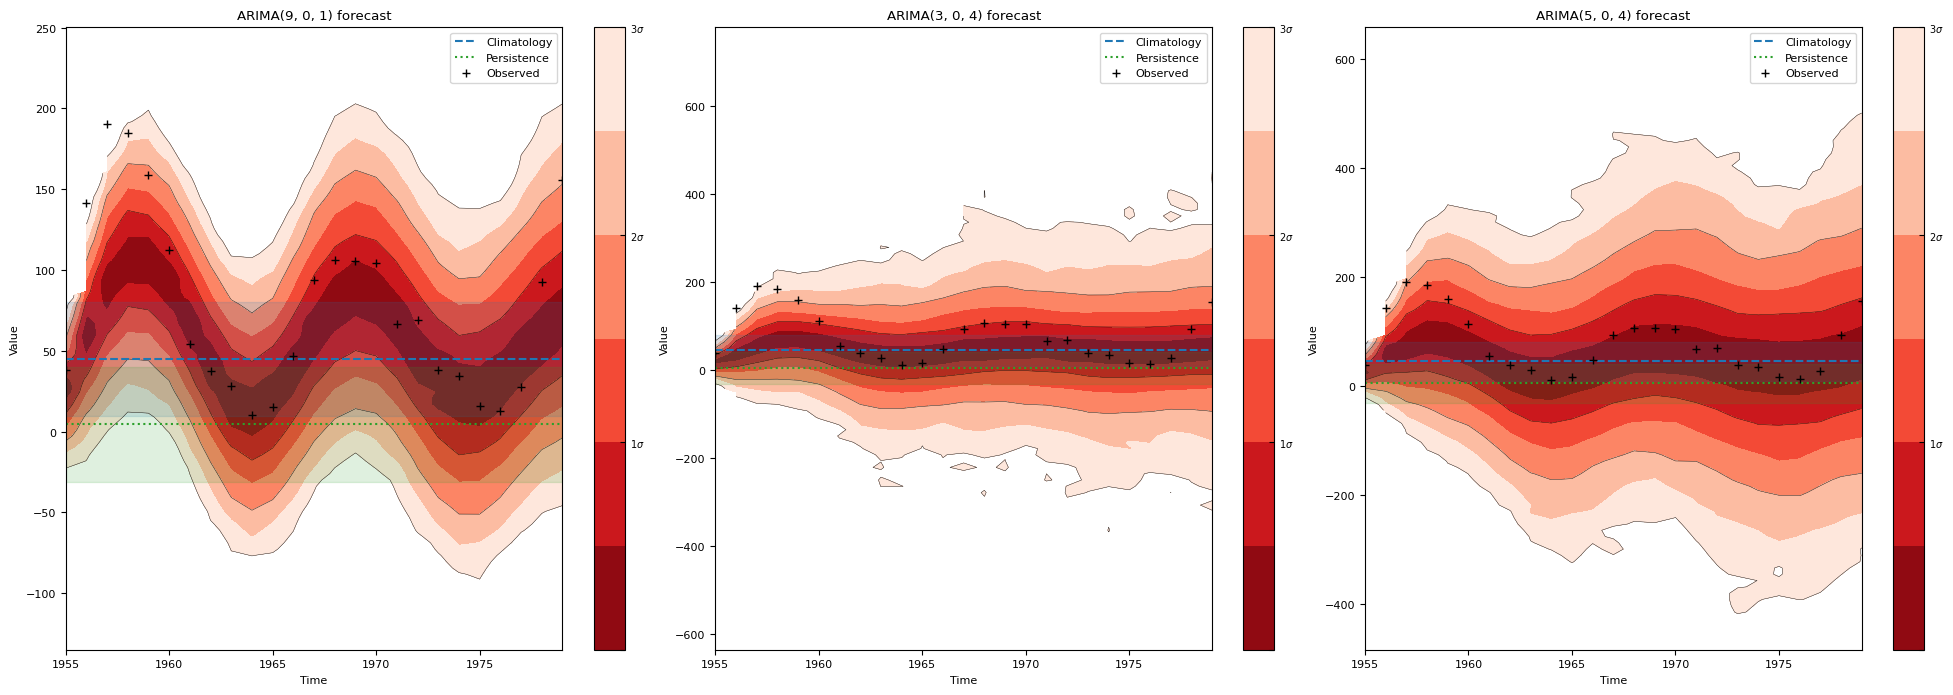

In [39]:
forecast_compare_fig, forecast_compare_ax = plt.subplots(1,3,figsize=(20,7))
posterior_data_54.outsample_forecast(time,counts,25,upper_index=final_index,n_samples=5000,ax=forecast_compare_ax[-1])
posterior_data_34.outsample_forecast(time,counts,25,upper_index=final_index,n_samples=5000,ax=forecast_compare_ax[1])
posterior_data_91.outsample_forecast(time,counts,25,upper_index=final_index,n_samples=5000,ax=forecast_compare_ax[0])